In [1]:
"""
RoBERTa-base Fake/Real classifier with:
- Grouped split by claim_id
- Label smoothing (calibration + robustness)
- Temperature scaling on validation logits
- Threshold tuning on validation probs
- Optional class weights (if imbalanced)
- Negation-only diagnostics (matches 'neg' in variant)
- Saves history.json for post-hoc plotting
- NEW: Train-split evaluation + confusion matrices + ROC/PR plots + history plot
"""

# ===================== 1) CONFIG =====================
RAW_PATH     = r"C:/Users/admin/Documents/PSM1_LAVEN/Datasets/Final_dataset_CVD19_ready_hardneg_bulk.csv"
# RAW_PATH  = r"C:/Users/admin/Documents/PSM1_LAVEN/Datasets/Final_dataset_CVD19_ready_sources_fixed.csv"

OUT_DIR      = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/BERT/outputs_robertabert"
MODEL_NAME   = "roberta-base"

SEED         = 42
MAX_LEN      = 320
BATCH_TRAIN  = 8
BATCH_EVAL   = 32

LR           = 1e-5
EPOCHS       = 5
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 0.01
GRAD_CLIP    = 1.0
LABEL_SMOOTH = 0.10

USE_CLASS_WEIGHTS = True

# ===================== 2) IMPORTS & SEED =====================
import os, json, unicodedata, random
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, get_linear_schedule_with_warmup
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, average_precision_score,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

import matplotlib.pyplot as plt

os.makedirs(OUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== 3) METRICS HELPERS =====================
def evaluate_split(y_true, proba_real, thr):
    preds = (proba_real >= thr).astype(int)
    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, preds, average="macro", zero_division=0
    )
    p_pc, r_pc, f1_pc, _ = precision_recall_fscore_support(
        y_true, preds, average=None, zero_division=0
    )
    cm = confusion_matrix(y_true, preds).tolist()
    roc = roc_auc_score(y_true, proba_real)
    pr_auc = average_precision_score(y_true, proba_real)
    return {
        "threshold": float(thr),
        "accuracy": float(acc),
        "macro_precision": float(prec),
        "macro_recall": float(rec),
        "macro_f1": float(f1),
        "per_class_precision_[fake,real]": [float(x) for x in p_pc],
        "per_class_recall_[fake,real]": [float(x) for x in r_pc],
        "per_class_f1_[fake,real]": [float(x) for x in f1_pc],
        "confusion_matrix_[[tn,fp],[fn,tp]]": cm,
        "roc_auc": float(roc),
        "pr_auc": float(pr_auc)
    }

# ---------- plotting helpers ----------
def save_confusion(y_true, proba, thr, title, path):
    preds = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["fake", "real"])
    fig, ax = plt.subplots(figsize=(4, 4), dpi=160)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path)
    plt.close(fig)

def save_roc_pr(y_true, proba, title_prefix, out_dir):
    fpr, tpr, _ = roc_curve(y_true, proba)
    precision, recall, _ = precision_recall_curve(y_true, proba)
    fig = plt.figure(figsize=(10, 4), dpi=160)

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title_prefix} ROC")

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} PR")

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{title_prefix.lower()}_roc_pr.png"))
    plt.close(fig)

def save_history_curves(history, out_dir):
    fig = plt.figure(figsize=(8, 4), dpi=160)
    plt.plot(history["epoch"], history["train_loss"], label="Train loss")
    plt.plot(history["epoch"], history["val_f1"], label="Val macro-F1")
    plt.plot(history["epoch"], history["val_acc"], label="Val acc")
    plt.xlabel("Epoch")
    plt.title("Training history")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "training_history.png"))
    plt.close(fig)

# ===================== 4) LOAD & SPLIT =====================
df = pd.read_csv(RAW_PATH, encoding="latin-1")
assert {"claim_id","text","label"}.issubset(df.columns), "Missing required columns: claim_id/text/label"

# normalize & drop exact duplicates (text+label)
df["text_clean"] = df["text"].astype(str).apply(lambda x: unicodedata.normalize("NFKC", x))
before = len(df)
df = df.drop_duplicates(subset=["text_clean","label"]).reset_index(drop=True)
print(f"Removed duplicates: {before - len(df)} | Remaining: {len(df)}")

# ensure numeric claim_id
df["claim_id"] = pd.to_numeric(df["claim_id"], errors="coerce").astype("Int64")
df = df.dropna(subset=["claim_id"]).reset_index(drop=True)

# grouped split (keep families together)
groups = df["claim_id"]
gss1 = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=SEED)
tr_idx, te_idx = next(gss1.split(df, groups=groups))
train_df, test_df = df.iloc[tr_idx].copy(), df.iloc[te_idx].copy()

gss2 = GroupShuffleSplit(test_size=0.10, n_splits=1, random_state=SEED)
tr2_idx, va_idx = next(gss2.split(train_df, groups=train_df["claim_id"]))
train_df, val_df = train_df.iloc[tr2_idx].copy(), train_df.iloc[va_idx].copy()

label_map = {"fake":0, "real":1}
for d in (train_df, val_df, test_df):
    d["label_id"] = d["label"].map(label_map).astype(int)

print({"train": len(train_df), "val": len(val_df), "test": len(test_df)})

# optional class weights
class_weights = None
if USE_CLASS_WEIGHTS:
    counts = train_df["label_id"].value_counts().reindex([0,1]).fillna(0).astype(int)
    total = counts.sum()
    w_fake = total / (2.0 * counts.loc[0]) if counts.loc[0] > 0 else 1.0
    w_real = total / (2.0 * counts.loc[1]) if counts.loc[1] > 0 else 1.0
    class_weights = torch.tensor([w_fake, w_real], dtype=torch.float32, device=device)
    print("Class weights [fake, real]:", class_weights.tolist())

# ===================== 5) DATASETS =====================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator  = DataCollatorWithPadding(tokenizer)

class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts); self.labels = list(labels)
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], truncation=True, max_length=MAX_LEN)
        item = {
            "input_ids": torch.tensor(enc["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(enc["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(int(self.labels[idx]), dtype=torch.long),
        }
        return item

ds_train = NewsDataset(train_df["text_clean"], train_df["label_id"])
ds_val   = NewsDataset(val_df["text_clean"],   val_df["label_id"])
ds_test  = NewsDataset(test_df["text_clean"],  test_df["label_id"])

train_loader      = DataLoader(ds_train, batch_size=BATCH_TRAIN, shuffle=True,  collate_fn=collator)
# NEW: non-shuffled train eval loader
train_eval_loader = DataLoader(ds_train, batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collator)
val_loader        = DataLoader(ds_val,   batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collator)
test_loader       = DataLoader(ds_test,  batch_size=BATCH_EVAL,  shuffle=False, collate_fn=collator)

# ===================== 6) MODEL & OPTIMS =====================
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# ---------- label-smoothed CE (per-sample) ----------
def ce_label_smooth_per_sample(logits, targets, eps=0.1):
    """
    returns tensor of shape [batch] with per-sample loss
    """
    num_classes = logits.size(-1)
    log_probs = F.log_softmax(logits, dim=-1)
    with torch.no_grad():
        true_dist = torch.zeros_like(log_probs)
        true_dist.fill_(eps / (num_classes - 1))
        true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - eps)
    loss = (-true_dist * log_probs).sum(dim=1)  # [batch]
    return loss

# ===================== 7) UTILS =====================
@torch.no_grad()
def eval_proba(loader, model_):
    model_.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        labels = batch["labels"].cpu().numpy()
        xb = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model_(**xb).logits
            probs = torch.softmax(logits, dim=-1)[:, 1].detach().cpu().numpy()
        all_probs.append(probs); all_labels.append(labels)
    return np.concatenate(all_probs), np.concatenate(all_labels)

@torch.no_grad()
def collect_logits_labels(loader, model_):
    model_.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        labels = batch["labels"].to(device)
        xb = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model_(**xb).logits
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())
    return torch.cat(all_logits, dim=0), torch.cat(all_labels, dim=0)

def probs_from_logits(logits, T=1.0):
    return torch.softmax(logits / T, dim=-1)[:, 1].cpu().numpy()

def tune_temperature(logits, labels):
    best_T, best_nll = 1.0, float("inf")
    for T in np.linspace(0.5, 3.0, 26):  # coarse
        nll = F.cross_entropy(logits / T, labels, reduction="mean").item()
        if nll < best_nll:
            best_T, best_nll = float(T), float(nll)
    lo = max(0.5, best_T - 0.5); hi = min(3.0, best_T + 0.5)  # refine
    for T in np.linspace(lo, hi, 21):
        nll = F.cross_entropy(logits / T, labels, reduction="mean").item()
        if nll < best_nll:
            best_T, best_nll = float(T), float(nll)
    return best_T

def tune_threshold(y_true, proba):
    best_thr, best_f1 = 0.5, -1.0
    for thr in np.linspace(0.05, 0.95, 91):
        _, _, f1, _ = precision_recall_fscore_support(
            y_true, (proba >= thr).astype(int), average="macro", zero_division=0
        )
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return float(best_thr), float(best_f1)

# ===================== 8) TRAIN =====================
best_state = None
best_val_f1 = -1.0
history = {"epoch": [], "train_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for batch in train_loader:
        labels = batch["labels"].to(device)
        xb = {k: v.to(device) for k, v in batch.items() if k != "labels"}

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(**xb).logits
            loss_vec = ce_label_smooth_per_sample(logits, labels, eps=LABEL_SMOOTH)
            if class_weights is not None:
                w = class_weights[labels]           # per-sample weights
                loss = (loss_vec * w).mean()
            else:
                loss = loss_vec.mean()

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        scheduler.step()
        running_loss += float(loss.item())

    # quick validation @ 0.5
    val_proba_05, y_val_np = eval_proba(val_loader, model)
    acc_05 = accuracy_score(y_val_np, (val_proba_05 >= 0.5).astype(int))
    _, _, f1_05, _ = precision_recall_fscore_support(
        y_val_np, (val_proba_05 >= 0.5).astype(int), average="macro", zero_division=0
    )
    print(f"Epoch {epoch}/{EPOCHS} | "
          f"train_loss={running_loss/len(train_loader):.4f} | "
          f"val_acc@0.5={acc_05:.3f} | val_macroF1@0.5={f1_05:.3f}")

    history["epoch"].append(epoch)
    history["train_loss"].append(float(running_loss/len(train_loader)))
    history["val_acc"].append(float(acc_05))
    history["val_f1"].append(float(f1_05))

    if f1_05 > best_val_f1:
        best_val_f1 = f1_05
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

# load best epoch
if best_state is not None:
    model.load_state_dict(best_state)
model.eval().to(device)

# save best weights + tokenizer + history
best_dir = os.path.join(OUT_DIR, "best_model")
os.makedirs(best_dir, exist_ok=True)
model.save_pretrained(best_dir); tokenizer.save_pretrained(best_dir)
with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)
print("Saved best epoch to", best_dir)

# ===================== 9) CALIBRATION & EVAL =====================
val_logits, y_val_t = collect_logits_labels(val_loader, model)
T_star = tune_temperature(val_logits, y_val_t)
val_proba = probs_from_logits(val_logits, T=T_star)
best_thr, best_f1 = tune_threshold(y_val_t.numpy(), val_proba)
print(f"Calibration: T*={T_star:.3f} | Best threshold (val)={best_thr:.2f} | val macro-F1={best_f1:.3f}")

test_logits, y_test_t = collect_logits_labels(test_loader, model)
test_proba = probs_from_logits(test_logits, T=T_star)

val_metrics  = evaluate_split(y_val_t.numpy(),  val_proba,  best_thr)
test_metrics = evaluate_split(y_test_t.numpy(), test_proba, best_thr)
print("VAL :", {k:v for k,v in val_metrics.items()  if k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})
print("TEST:", {k:v for k,v in test_metrics.items() if k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})

# ---- TRAIN EVAL (calibrated with T* and using best_thr from val) ----
train_logits, y_train_t = collect_logits_labels(train_eval_loader, model)
train_proba = probs_from_logits(train_logits, T=T_star)
train_metrics = evaluate_split(y_train_t.numpy(), train_proba, best_thr)
print("TRAIN:", {k:v for k,v in train_metrics.items()
                if k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})

# negation-only diagnostics
if "variant" in test_df.columns:
    neg_mask = test_df["variant"].astype(str).str.contains("neg", case=False, na=False)
    if neg_mask.any():
        y_true_neg = y_test_t.numpy()[neg_mask.values]
        proba_neg  = test_proba[neg_mask.values]
        neg_metrics = evaluate_split(y_true_neg, proba_neg, best_thr)  # global threshold
        print(f"NEGATION SUBSET (using global thr={best_thr:.2f}):",
              {k:v for k,v in neg_metrics.items() if k in ["accuracy","macro_f1","roc_auc","pr_auc"]},
              f"| n={int(neg_mask.sum())}")
    else:
        print("No 'neg' variants detected in test set.")

# paraphrase/variant consistency (same claim: all agree)
test_preds = (test_proba >= best_thr).astype(int)
test_claims = test_df["claim_id"].values
df_eval = pd.DataFrame({"claim_id": test_claims, "pred": test_preds})
multi = df_eval.groupby("claim_id").filter(lambda g: len(g) > 1).groupby("claim_id")
multi_total = len(list(multi.groups.keys()))
consistent = sum(1 for _, g in multi if g["pred"].nunique() == 1)
para_consistency = float(consistent / multi_total) if multi_total > 0 else float("nan")
print(f"Paraphrase consistency (test): {para_consistency:.3f} over {multi_total} multi-variant claims")

# ===================== 10) SAVE ARTIFACTS =====================
# Confusion Matrices
save_confusion(y_train_t.numpy(), train_proba, best_thr,
               "Train Confusion Matrix", os.path.join(OUT_DIR, "cm_train.png"))
save_confusion(y_val_t.numpy(),   val_proba,   best_thr,
               "Val Confusion Matrix",   os.path.join(OUT_DIR, "cm_val.png"))
save_confusion(y_test_t.numpy(),  test_proba,  best_thr,
               "Test Confusion Matrix",  os.path.join(OUT_DIR, "cm_test.png"))

# ROC & PR Curves
save_roc_pr(y_train_t.numpy(), train_proba, "Train", OUT_DIR)
save_roc_pr(y_val_t.numpy(),   val_proba,   "Val",   OUT_DIR)
save_roc_pr(y_test_t.numpy(),  test_proba,  "Test",  OUT_DIR)

# History curve
save_history_curves(history, OUT_DIR)

metrics = {
    "label_smoothing": LABEL_SMOOTH,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "temperature": float(T_star),
    "best_threshold": float(best_thr),
    "train": train_metrics,      # <--- added
    "val": val_metrics,
    "test": test_metrics,
    "paraphrase_consistency_test": float(para_consistency)
}
with open(os.path.join(OUT_DIR, "robertabert_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

preds_out = pd.DataFrame({
    "claim_id": test_df["claim_id"],
    "true_label": test_df["label"],
    "proba_real": test_proba,
    "pred_label": np.where(test_preds==1, "real", "fake")
})
preds_out.to_csv(os.path.join(OUT_DIR, "robertabert_test_predictions.csv"),
                 index=False, encoding="utf-8")

print("Saved:", {
    "best_model_dir": os.path.join(OUT_DIR, "best_model"),
    "metrics_json": os.path.join(OUT_DIR, "robertabert_metrics.json"),
    "history_json": os.path.join(OUT_DIR, "history.json"),
    "test_predictions": os.path.join(OUT_DIR, "robertabert_test_predictions.csv"),
    "cm_train": os.path.join(OUT_DIR, "cm_train.png"),
    "cm_val": os.path.join(OUT_DIR, "cm_val.png"),
    "cm_test": os.path.join(OUT_DIR, "cm_test.png"),
    "roc_pr_train": os.path.join(OUT_DIR, "train_roc_pr.png"),
    "roc_pr_val": os.path.join(OUT_DIR, "val_roc_pr.png"),
    "roc_pr_test": os.path.join(OUT_DIR, "test_roc_pr.png"),
    "training_history": os.path.join(OUT_DIR, "training_history.png"),
})


Removed duplicates: 0 | Remaining: 24537
{'train': 17668, 'val': 1941, 'test': 4928}
Class weights [fake, real]: [0.9626239538192749, 1.040395736694336]


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\admin\AppData\Local\Temp\ipykernel_7580\3420141769.py:219: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
C:\Users\admin\anaconda3\envs\my_bert_gpu_env\lib\site-packages\transformers\utils\generic.py:280: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converte

Epoch 1/5 | train_loss=0.5797 | val_acc@0.5=0.877 | val_macroF1@0.5=0.876


C:\Users\admin\anaconda3\envs\my_bert_gpu_env\lib\site-packages\transformers\utils\generic.py:280: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  arr = np.array(obj)
C:\Users\admin\AppData\Local\Temp\ipykernel_7580\3420141769.py:302: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
C:\Users\admin\AppData\Local\Temp\ipykernel_7580\3420141769.py:243: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cu

Epoch 2/5 | train_loss=0.4734 | val_acc@0.5=0.901 | val_macroF1@0.5=0.901


...

Calibration: T*=0.900 | Best threshold (val)=0.81 | val macro-F1=0.911


C:\Users\admin\anaconda3\envs\my_bert_gpu_env\lib\site-packages\transformers\utils\generic.py:280: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  arr = np.array(obj)
C:\Users\admin\AppData\Local\Temp\ipykernel_7580\3420141769.py:256: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


VAL : {'accuracy': 0.9119010819165378, 'macro_precision': 0.9126075514259627, 'macro_recall': 0.9101763220953626, 'macro_f1': 0.9111538983515433, 'roc_auc': 0.9605725983162265, 'pr_auc': 0.9493974240247589}
TEST: {'accuracy': 0.9017857142857143, 'macro_precision': 0.9022903169090011, 'macro_recall': 0.9006991805445413, 'macro_f1': 0.9013103985316254, 'roc_auc': 0.9572279771345493, 'pr_auc': 0.9396619261204618}


C:\Users\admin\anaconda3\envs\my_bert_gpu_env\lib\site-packages\transformers\utils\generic.py:280: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  arr = np.array(obj)
C:\Users\admin\AppData\Local\Temp\ipykernel_7580\3420141769.py:256: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


TRAIN: {'accuracy': 0.9439664930948608, 'macro_precision': 0.9446578609742339, 'macro_recall': 0.9433360633743217, 'macro_f1': 0.943809463268021, 'roc_auc': 0.9823293659894645, 'pr_auc': 0.9804061059947283}
NEGATION SUBSET (using global thr=0.81): {'accuracy': 0.7851002865329513, 'macro_f1': 0.7850500888268019, 'roc_auc': 0.862430331475506, 'pr_auc': 0.8480284262100309} | n=1047
Paraphrase consistency (test): 0.215 over 735 multi-variant claims
Saved: {'best_model_dir': 'C:/Users/admin/Documents/PSM1_LAVEN/Model/BERT/outputs_robertabert\\best_model', 'metrics_json': 'C:/Users/admin/Documents/PSM1_LAVEN/Model/BERT/outputs_robertabert\\robertabert_metrics.json', 'history_json': 'C:/Users/admin/Documents/PSM1_LAVEN/Model/BERT/outputs_robertabert\\history.json', 'test_predictions': 'C:/Users/admin/Documents/PSM1_LAVEN/Model/BERT/outputs_robertabert\\robertabert_test_predictions.csv', 'cm_train': 'C:/Users/admin/Documents/PSM1_LAVEN/Model/BERT/outputs_robertabert\\cm_train.png', 'cm_val': '

In [2]:
# === Common setup (run once) ===
import os, json, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, average_precision_score, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

# Use one test CSV for ALL models so the texts are identical
DATA_CSV      = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/BERT/outputs_robertabert/test_clean.csv"
ENCODING      = "latin-1"
OUT_DIR_BASE  = r"C:/Users/admin/Documents/PSM1_LAVEN/Appendix_Evals"

os.makedirs(OUT_DIR_BASE, exist_ok=True)

def normalize_text_series(s: pd.Series) -> pd.Series:
    return s.astype(str).apply(lambda x: unicodedata.normalize("NFKC", x))

def ensure_columns(df: pd.DataFrame):
    need = {"claim_id", "text", "label"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

def map_labels(df: pd.DataFrame) -> np.ndarray:
    labmap = {"fake": 0, "real": 1}
    y = df["label"].astype(str).str.lower().map(labmap)
    if y.isna().any():
        bad = df.loc[y.isna(), "label"].unique().tolist()
        raise ValueError(f"Unknown labels in dataset: {bad}. Expected only 'fake' or 'real'.")
    return y.astype(int).values

def evaluate_split(y_true: np.ndarray, proba_real: np.ndarray, thr: float):
    preds = (proba_real >= thr).astype(int)
    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="macro", zero_division=0)
    p_pc, r_pc, f1_pc, _ = precision_recall_fscore_support(y_true, preds, average=None, zero_division=0)
    cm = confusion_matrix(y_true, preds).tolist()
    try:
        roc = float(roc_auc_score(y_true, proba_real))
    except Exception:
        roc = float("nan")
    try:
        pr_auc = float(average_precision_score(y_true, proba_real))
    except Exception:
        pr_auc = float("nan")
    return ({
        "threshold": float(thr),
        "accuracy": float(acc),
        "macro_precision": float(prec),
        "macro_recall": float(rec),
        "macro_f1": float(f1),
        "per_class_precision_[fake,real]": [float(x) for x in p_pc],
        "per_class_recall_[fake,real]": [float(x) for x in r_pc],
        "per_class_f1_[fake,real]": [float(x) for x in f1_pc],
        "confusion_matrix_[[tn,fp],[fn,tp]]": cm,
        "roc_auc": roc,
        "pr_auc": pr_auc
    }, preds)

def save_confusion(y_true, proba, thr, title, path_png):
    preds = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["fake", "real"])
    fig, ax = plt.subplots(figsize=(4, 4), dpi=160)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(path_png)
    plt.show()
    plt.close(fig)

def save_roc_pr(y_true, proba, title_prefix, out_dir):
    try:
        fpr, tpr, _ = roc_curve(y_true, proba)
        precision, recall, _ = precision_recall_curve(y_true, proba)
    except Exception:
        return
    fig = plt.figure(figsize=(10, 4), dpi=160)

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"{title_prefix} ROC")

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} PR")

    plt.tight_layout()
    out_path = os.path.join(out_dir, f"{title_prefix.lower()}_roc_pr.png")
    plt.savefig(out_path)
    plt.show()
    plt.close(fig)

def maybe_negation_subset(df: pd.DataFrame, y_true: np.ndarray, proba: np.ndarray, thr: float):
    if "variant" not in df.columns:
        return None
    mask = df["variant"].astype(str).str.contains("neg", case=False, na=False)
    if not mask.any():
        return None
    neg_y = y_true[mask.values]
    neg_pr = proba[mask.values]
    neg_metrics, _ = evaluate_split(neg_y, neg_pr, thr)
    return {k: neg_metrics[k] for k in ["accuracy", "macro_f1", "roc_auc", "pr_auc"]} | {"n": int(mask.sum())}

print("Common setup ready. Using DATA_CSV =", DATA_CSV)


Common setup ready. Using DATA_CSV = C:/Users/admin/Documents/PSM1_LAVEN/Model/BERT/outputs_robertabert/test_clean.csv


=== 10 random examples ===


,claim_id,text_short,label,pred_label,proba_real,correct
1665,3562,False image and note spread claiming to be written by a university president that the heat from a hair dryer can kill coronavirus germs,fake,fake,0.070274,True
3592,11656,"n.b. covid-19 roundup: no new cases for 9th straight day, but province isn't ready to 'declare victory'",real,real,0.932130,True
2726,8063,spraying with boiling water eliminates the new coronavirus.,fake,fake,0.069033,True
2380,6505,"a message of key takeaways from an interview of hdfc bank md & ceo aditya puri, where he has said how india will survive the coronavirus pandemic.",fake,fake,0.073762,True
676,519,"As a point of comparison, cigarettes are approved by the FDA.",fake,real,0.903708,False
290,218,"Individual studies on sun exposure and health undergo peer review; alleging they are a ""cover-upÂ for vaccine side effects conflates unrelated research topics without evidence.",real,real,0.930036,True
577,430,Reports suggest the UK's Prime Minister's booster was not a fake.,real,real,0.933881,True
2561,7297,"a french doctor is not quoted as saying that us billionaire bill gates wants to sell a covid-19 vaccine in africa, but it's poisonous and will destroy africa.",real,real,0.935713,True
1519,2968,It is not true that Cebu City looking for own quarantine facility for residents with suspected 2019-nCov,fake,fake,0.084346,True
2194,5727,"coronavirus outbreak updates: maharashtras cases sur..est positive; toll mounts to 5,984 with 160 fatalities",real,real,0.933961,True



=== 5 most confident REAL (highest proba_real) ===


,claim_id,text_short,label,pred_label,proba_real,correct
2083,5218,"2019 coronavirus cannot live for ""up to 3 hours in the air, up to 4 hours on copper, up to 24 hours on cardboard up to 3 days on plastic and stainless steel.",fake,real,0.942146,False
4336,14311,The strongest Covid-19 immunity comes from both vaccination and previous infection.,real,real,0.937881,True
1793,4073,"philippine education secretary leonor briones is not shown quoted as saying classes will resume on aug. 24 amid the covid-19 pandemic and that if we die, we die.",real,real,0.937820,True
4238,14213,Teens in Malaysia became eligible for Pfizer doses starting 2021.,real,real,0.937728,True
4235,14212,Pfizer's mRNA vaccine gained standard approval for 16 and older in Aug 2021.,real,real,0.937278,True



=== 5 most confident FAKE (lowest proba_real) ===


,claim_id,text_short,label,pred_label,proba_real,correct
3051,9371,the covid-19 test kits from a korean company are deemed suspicious by u.s. congress.,fake,fake,0.064594,True
2066,5123,"walmart, amazon, kroger, target and costco have not had any reported (coronavirus) cases in the news.",fake,fake,0.064719,True
3786,12520,city of edmonton employee confirmed to have not travel-related covid-19,fake,fake,0.065025,True
2811,8398,news ticker added to an image from sri lankan ada derana tv channel gives the impression that dr seetha arambepola stated there is a secret medicine for covid-19 during a tv interview,fake,fake,0.065634,True
1772,4013,good oral hygiene destroys the coronavirus and prevents its spread,fake,fake,0.065742,True



=== Top 5 MISCLASSIFICATIONS (n=483) ===


C:\Users\admin\AppData\Local\Temp\ipykernel_7580\3964642947.py:159: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mistakes["conf_margin"] = np.where(mistakes["pred_label"]=="real",


,claim_id,text_short,label,pred_label,proba_real
2083,5218,"2019 coronavirus cannot live for ""up to 3 hours in the air, up to 4 hours on copper, up to 24 hours on cardboard up to 3 days on plastic and stainless steel.",fake,real,0.942146
3327,10509,"death toll in wuhan due to coronavirus reaches 10,000 people",fake,real,0.936612
125,96,COVID-19 vaccines cannot transfer through sexual contact or 'shed' to others.,fake,real,0.936575
54,36,COVID-19 does spread through drinking water; no credible data shows viral surges in the water supply.,fake,real,0.935479
2041,5041,says joe biden has not said 150 million americans died from guns and another 120 million from covid-19,fake,real,0.935422


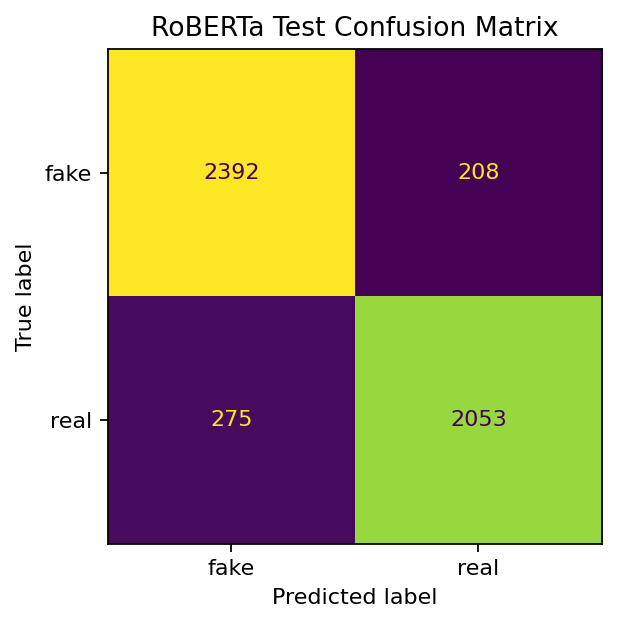

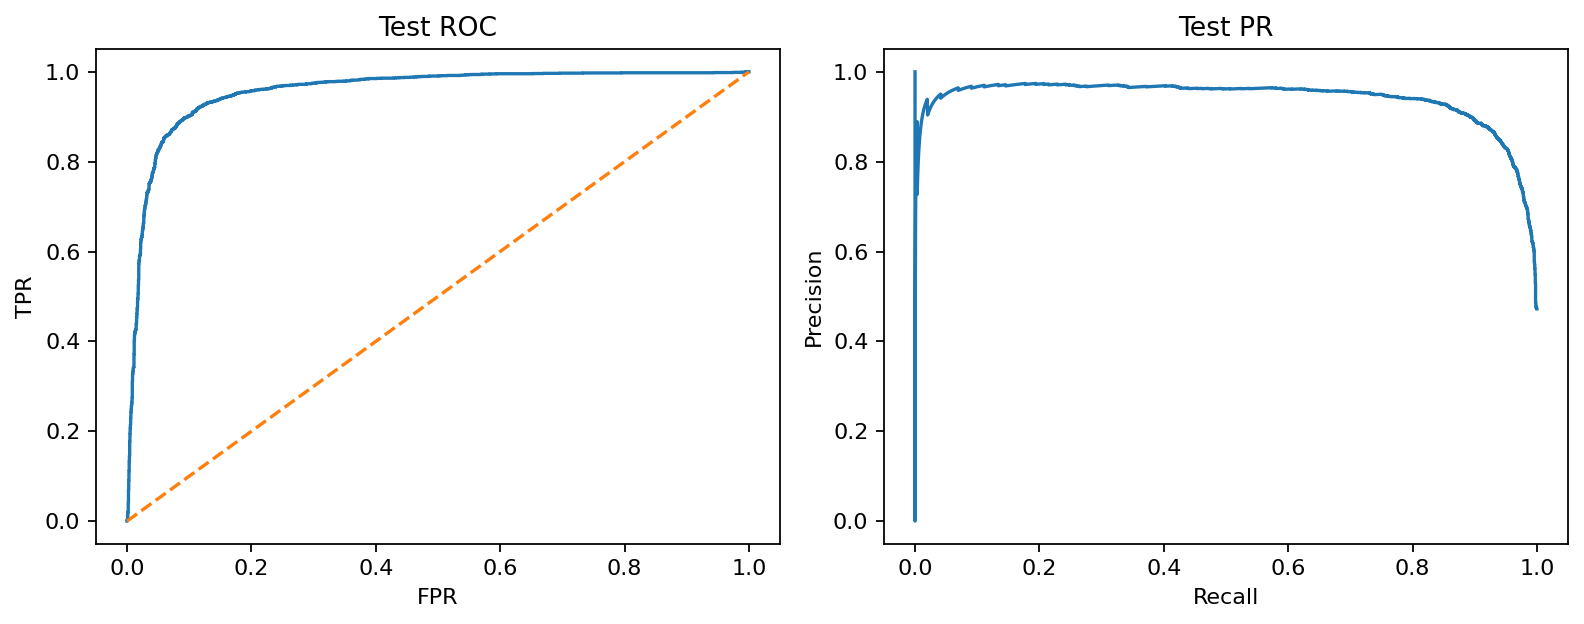


Summary: {'accuracy': 0.9019886363636364, 'macro_precision': 0.9024465981999927, 'macro_recall': 0.9009364261168384, 'macro_f1': 0.9015226272051735, 'roc_auc': 0.957191630319852, 'pr_auc': 0.9395883597758397}
Artifacts saved to: C:/Users/admin/Documents/PSM1_LAVEN/Appendix_Evals/roberta_examples


In [5]:
# RoBERTa test WITH EXAMPLE TEXT OUTPUTS (same texts as LogReg/SVC)
import os, json, unicodedata, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay, roc_curve, precision_recall_curve)

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

# ---------- PATHS (adjust if yours differ) ----------
DATA_CSV     = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/Logistic Regression + TF-IDF/outputs_lr_tfidf/test_clean.csv"
MODEL_DIR    = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/BERT/outputs_robertabert/best_model"
METRICS_JSON = r"C:/Users/admin/Documents/PSM1_LAVEN/Model/BERT/outputs_robertabert/robertabert_metrics.json"
OUT_DIR      = r"C:/Users/admin/Documents/PSM1_LAVEN/Appendix_Evals/roberta_examples"
ENCODING     = "latin-1"
MAX_LEN      = 320
BATCH_SIZE   = 64

os.makedirs(OUT_DIR, exist_ok=True)

# ---------- helpers ----------
def normalize_text_series(s: pd.Series) -> pd.Series:
    return s.astype(str).apply(lambda x: unicodedata.normalize("NFKC", x))

def ensure_columns(df: pd.DataFrame):
    need = {"claim_id", "text", "label"}
    missing = need - set(df.columns)
    if missing: raise ValueError(f"Missing columns: {missing}")

def map_labels(df: pd.DataFrame) -> np.ndarray:
    labmap = {"fake":0, "real":1}
    y = df["label"].astype(str).str.lower().map(labmap)
    if y.isna().any():
        raise ValueError(f"Unknown labels: {df.loc[y.isna(),'label'].unique().tolist()}")
    return y.astype(int).values

def evaluate_split(y_true, proba_real, thr):
    preds = (proba_real >= thr).astype(int)
    acc = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="macro", zero_division=0)
    p_pc, r_pc, f1_pc, _ = precision_recall_fscore_support(y_true, preds, average=None, zero_division=0)
    cm = confusion_matrix(y_true, preds).tolist()
    try: roc = float(roc_auc_score(y_true, proba_real))
    except: roc = float("nan")
    try: pr = float(average_precision_score(y_true, proba_real))
    except: pr = float("nan")
    return ({
        "threshold": float(thr),
        "accuracy": float(acc),
        "macro_precision": float(prec),
        "macro_recall": float(rec),
        "macro_f1": float(f1),
        "per_class_precision_[fake,real]": [float(x) for x in p_pc],
        "per_class_recall_[fake,real]": [float(x) for x in r_pc],
        "per_class_f1_[fake,real]": [float(x) for x in f1_pc],
        "confusion_matrix_[[tn,fp],[fn,tp]]": cm,
        "roc_auc": roc, "pr_auc": pr
    }, preds)

def save_confusion(y_true, proba, thr, title, path):
    preds = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["fake","real"])
    fig, ax = plt.subplots(figsize=(4,4), dpi=160)
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout(); plt.savefig(path); plt.show(); plt.close(fig)

def save_roc_pr(y_true, proba, title_prefix, out_dir):
    try:
        fpr, tpr, _ = roc_curve(y_true, proba)
        prec, rec, _ = precision_recall_curve(y_true, proba)
    except Exception:
        return
    fig = plt.figure(figsize=(10,4), dpi=160)
    plt.subplot(1,2,1); plt.plot(fpr,tpr); plt.plot([0,1],[0,1],"--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"{title_prefix} ROC")
    plt.subplot(1,2,2); plt.plot(rec,prec)
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(f"{title_prefix} PR")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, f"{title_prefix.lower()}_roc_pr.png")); plt.show(); plt.close(fig)

def shorten(s, n=200):
    s = str(s)
    return s if len(s) <= n else s[:n-1] + "…"

# ---------- load data ----------
df = pd.read_csv(DATA_CSV, encoding=ENCODING)
ensure_columns(df)
if "text_clean" not in df.columns:
    df["text_clean"] = normalize_text_series(df["text"])
y_true = map_labels(df)

# ---------- load model/metrics ----------
thr, T = 0.5, 1.0
if os.path.isfile(METRICS_JSON):
    m = json.load(open(METRICS_JSON, "r"))
    thr = float(m.get("best_threshold", thr))
    T   = float(m.get("temperature", T))

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
collator = DataCollatorWithPadding(tokenizer)

class TxtDS(Dataset):
    def __init__(self, s): self.s = list(s)
    def __len__(self): return len(self.s)
    def __getitem__(self, i): return tokenizer(self.s[i], truncation=True, max_length=MAX_LEN)

dl = DataLoader(TxtDS(df["text_clean"]), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)

# ---------- inference ----------
all_probs = []
with torch.no_grad():
    for batch in dl:
        xb = {k: v.to(device) for k, v in batch.items()}
        logits = model(**xb).logits
        probs = torch.softmax(logits / T, dim=-1)[:, 1].detach().cpu().numpy()
        all_probs.append(probs)
proba = np.concatenate(all_probs)
metrics, preds = evaluate_split(y_true, proba, thr)

# ---------- build a rich results table ----------
res = df[["claim_id","text","label"]].copy()
res["proba_real"] = proba
res["pred_label"] = np.where(proba >= thr, "real", "fake")
res["correct"]    = (res["pred_label"].str.lower() == res["label"].str.lower())
res["text_short"] = res["text"].apply(lambda s: shorten(s, 220))

# SAVE full predictions for appendix
res[["claim_id","text","label","proba_real","pred_label","correct"]].to_csv(
    os.path.join(OUT_DIR, "predictions_test.csv"), index=False, encoding="utf-8"
)

# ---------- show EXAMPLES right here ----------
pd.set_option("display.max_colwidth", 240)

print("=== 10 random examples ===")
display(res.sample(10, random_state=42)[["claim_id","text_short","label","pred_label","proba_real","correct"]])

print("\n=== 5 most confident REAL (highest proba_real) ===")
display(res.sort_values("proba_real", ascending=False).head(5)[
    ["claim_id","text_short","label","pred_label","proba_real","correct"]
])

print("\n=== 5 most confident FAKE (lowest proba_real) ===")
display(res.sort_values("proba_real", ascending=True).head(5)[
    ["claim_id","text_short","label","pred_label","proba_real","correct"]
])

mistakes = res[~res["correct"]]
if len(mistakes) > 0:
    print(f"\n=== Top 5 MISCLASSIFICATIONS (n={len(mistakes)}) ===")
    # choose the most confident wrong ones
    mistakes["conf_margin"] = np.where(mistakes["pred_label"]=="real",
                                       mistakes["proba_real"],
                                       1.0 - mistakes["proba_real"])
    display(mistakes.sort_values("conf_margin", ascending=False).head(5)[
        ["claim_id","text_short","label","pred_label","proba_real"]
    ])
else:
    print("\n=== No misclassifications in this split ===")

# ---------- plots (optional for appendix) ----------
save_confusion(y_true, proba, thr, "RoBERTa Test Confusion Matrix", os.path.join(OUT_DIR, "cm_test.png"))
save_roc_pr(y_true, proba, "Test", OUT_DIR)

# ---------- store metrics ----------
with open(os.path.join(OUT_DIR, "metrics_test.json"), "w") as f:
    json.dump({"model_type":"roberta", "temperature_used":T, "threshold_used":thr, "test":metrics}, f, indent=2)

print("\nSummary:", {k: metrics[k] for k in ["accuracy","macro_precision","macro_recall","macro_f1","roc_auc","pr_auc"]})
print("Artifacts saved to:", OUT_DIR)
